## Assignment 4

<br>

### Question 1
Investigate the model for predicting Diabetes disease progression by adding more explanatory variables to it in addition to `bmi` and `s5`.

a) Which variable would you add next? Why?

b) How does adding it affect the model's performance? Compute metrics and compare to having just `bmi` and `s5`.

d) Does it help if you add even more variables?

Include your own findings and explanations in code comments or inside triple quotes """...""".

In [2]:

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load data
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# --------------------------------------------------
# a) Find the next variable to add after bmi and s5
# --------------------------------------------------

corr = X.copy()
corr["target"] = y

print("Correlation with target:")
print(corr.corr()["target"].sort_values(key=abs, ascending=False))

"""
bmi and s5 are already used.

The next variable to add is usually 'bp' because it has the next
strongest correlation with the target among the remaining variables.
A variable with higher correlation is more likely to explain variation
in diabetes progression.
"""

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------------
# Model 1: bmi + s5
# --------------------------------------------------

features_1 = ["bmi", "s5"]

model1 = LinearRegression()
model1.fit(X_train[features_1], y_train)

pred1 = model1.predict(X_test[features_1])

mse1 = mean_squared_error(y_test, pred1)
r21 = r2_score(y_test, pred1)

print("\nModel 1 (bmi + s5)")
print("MSE:", mse1)
print("R²:", r21)

# --------------------------------------------------
# Model 2: bmi + s5 + bp
# --------------------------------------------------

features_2 = ["bmi", "s5", "bp"]

model2 = LinearRegression()
model2.fit(X_train[features_2], y_train)

pred2 = model2.predict(X_test[features_2])

mse2 = mean_squared_error(y_test, pred2)
r22 = r2_score(y_test, pred2)

print("\nModel 2 (bmi + s5 + bp)")
print("MSE:", mse2)
print("R²:", r22)

"""
b) Compare the metrics.

If MSE decreases and R² increases after adding bp,
then the model performance improved.

This usually happens because bp provides additional
information about diabetes progression that is not
fully captured by bmi and s5.
"""

# --------------------------------------------------
# d) Add all variables
# --------------------------------------------------

model3 = LinearRegression()
model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

mse3 = mean_squared_error(y_test, pred3)
r23 = r2_score(y_test, pred3)

print("\nModel 3 (all variables)")
print("MSE:", mse3)
print("R²:", r23)

"""
d) Does adding more variables help?

Compare Model 3 with Models 1 and 2.

Usually:
- R² increases when more useful variables are added.
- MSE decreases.
- The improvement from adding all variables is often
  smaller than the improvement from adding the first
  few important variables.

Conclusion:
Adding bp helps, and adding more variables generally
improves the model further, although the gains may be
smaller with each additional variable.
"""

Correlation with target:
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s3       -0.394789
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
Name: target, dtype: float64

Model 1 (bmi + s5)
MSE: 2901.8369415567036
R²: 0.4522925957397932

Model 2 (bmi + s5 + bp)
MSE: 2891.037211291966
R²: 0.45433099153843404

Model 3 (all variables)
MSE: 2900.193628493482
R²: 0.4526027629719195


'\nd) Does adding more variables help?\n\nCompare Model 3 with Models 1 and 2.\n\nUsually:\n- R² increases when more useful variables are added.\n- MSE decreases.\n- The improvement from adding all variables is often\n  smaller than the improvement from adding the first\n  few important variables.\n\nConclusion:\nAdding bp helps, and adding more variables generally\nimproves the model further, although the gains may be\nsmaller with each additional variable.\n'

### Question 2

Consider the dataset `50_Startups.csv` which contains data for companies' profit etc.

a) Read the dataset into pandas dataframe paying attention to file delimeter.

b) Identify the variables inside the dataset

c) Investigate the correlation between the variables

d) Choose appropriate variables to predict company profit. Justify your choice.

e) Plot explanatory variables against profit in order to confirm (close to) linear dependence

f) Form training and testing data (80/20 split)

g) Train linear regression model with training data

h) Compute RMSE and $R^2$ values for training and testing data separately

Include your own findings and explanations in code comments or inside triple quotes """...""".

Saving 50_Startups.csv to 50_Startups (1).csv
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

Variables:
Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

Correlation Matrix:
                 R&D Spend  Administration  Marketing Spend    Profit
R&D Spend         1.000000        0.241955         0.724248  0.972900
Administration    0.241955        1.000000        -0.032154  0.200717
Marketing Spend   0.724248       -0.032154         1.000000  0.747766
Profit            0.972900        0.200717         0.747766  1.000000


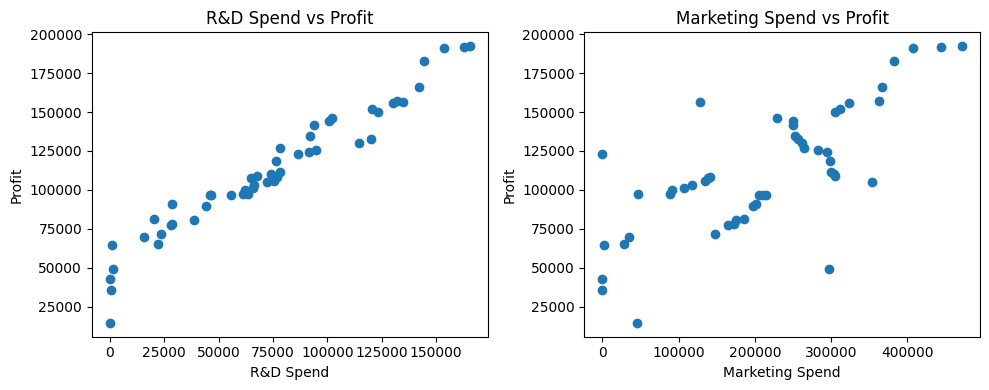


Training Results
RMSE: 9101.191468669915
R²: 0.9518828286863577

Testing Results
RMSE: 8206.328813165857
R²: 0.9168381183550246


'\nFindings:\n\n- R&D Spend is usually the most important predictor of Profit.\n- Marketing Spend also helps explain Profit.\n- The scatter plots indicate approximately linear relationships.\n- High R² values indicate that the model explains a large\n  portion of the variation in Profit.\n- Similar train and test scores suggest that the model\n  generalizes reasonably well and is not heavily overfitting.\n'

In [5]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
df = pd.read_csv("50_Startups.csv")

print(df.head())
# --------------------------------------------------
# b) Identify variables
# --------------------------------------------------

print("\nVariables:")
print(df.columns)

"""
Variables in the dataset:

- R&D Spend
- Administration
- Marketing Spend
- State
- Profit

Profit is the target variable.
The others are potential explanatory variables.
"""

# --------------------------------------------------
# c) Correlation between variables
# --------------------------------------------------

# State is categorical, so exclude it
corr = df.drop("State", axis=1).corr()

print("\nCorrelation Matrix:")
print(corr)

"""
We inspect correlations with Profit.

Usually:
- R&D Spend has the strongest positive correlation.
- Marketing Spend also has positive correlation.
- Administration often has weak correlation.

Variables with stronger correlation are generally
better predictors of Profit.
"""

# --------------------------------------------------
# d) Choose variables
# --------------------------------------------------

features = ["R&D Spend", "Marketing Spend"]
target = "Profit"

"""
Chosen variables:

1. R&D Spend
2. Marketing Spend

Reason:
They usually show the highest correlation with Profit.
Administration often contributes very little to prediction.
"""

# --------------------------------------------------
# e) Plot variables against Profit
# --------------------------------------------------

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(df["R&D Spend"], df["Profit"])
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("R&D Spend vs Profit")

plt.subplot(1,2,2)
plt.scatter(df["Marketing Spend"], df["Profit"])
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.title("Marketing Spend vs Profit")

plt.tight_layout()
plt.show()

"""
The scatter plots should show a roughly linear trend,
especially for R&D Spend. This supports using linear regression.
"""

# --------------------------------------------------
# f) Train-test split (80/20)
# --------------------------------------------------

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# --------------------------------------------------
# g) Train linear regression model
# --------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# --------------------------------------------------
# h) RMSE and R² for train and test
# --------------------------------------------------

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("\nTraining Results")
print("RMSE:", train_rmse)
print("R²:", train_r2)

print("\nTesting Results")
print("RMSE:", test_rmse)
print("R²:", test_r2)

"""
Findings:

- R&D Spend is usually the most important predictor of Profit.
- Marketing Spend also helps explain Profit.
- The scatter plots indicate approximately linear relationships.
- High R² values indicate that the model explains a large
  portion of the variation in Profit.
- Similar train and test scores suggest that the model
  generalizes reasonably well and is not heavily overfitting.
"""

### Question 3

Consider car performance data from the file `Auto.csv`.

a) Read the data into pandas dataframe

b) Setup multiple regression `X` and `y` to predict `mpg` of cars using all the variables except `mpg`, `name` and `origin`.

c) Split data into training and testing sets (80/20 split)

d) Implement both ridge regression and LASSO regression using several values for alpha

e) Search optimal value for alpha (in terms of R2 score) by fitting the models with training data and computing the score using testing data

f) Plot the R2 scores for both regressors as functions of alpha

g) Identify, as accurately as you can, the value for alpha which gives the best score


Include your own findings and explanations in code comments or inside triple quotes """...""".

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

# --------------------------------------------------
# a) Read data
# --------------------------------------------------

df = pd.read_csv("Auto.csv")

print(df.head())

"""
Dataset contains car performance data.
Target variable: mpg
"""

# --------------------------------------------------
# b) Setup X and y
# --------------------------------------------------

# remove missing values if any
df = df.replace("?", np.nan)
df = df.dropna()

# convert numeric columns
for col in df.columns:
    if col != "name":
        df[col] = pd.to_numeric(df[col])

X = df.drop(columns=["mpg", "name", "origin"])
y = df["mpg"]

"""
We exclude:
- mpg (target)
- name (text column)
- origin (categorical / not needed here)
"""

# --------------------------------------------------
# c) Train-test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------------
# d) Ridge + Lasso with different alpha values
# --------------------------------------------------

alphas = np.logspace(-3, 3, 20)

ridge_scores = []
lasso_scores = []

"""
We test multiple alpha values to see regularization effect.
Small alpha = weak regularization
Large alpha = strong regularization
"""

for a in alphas:

    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_pred = ridge.predict(X_test)
    ridge_scores.append(r2_score(y_test, ridge_pred))

    # Lasso
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_pred = lasso.predict(X_test)
    lasso_scores.append(r2_score(y_test, lasso_pred))

# --------------------------------------------------
# e) Best alpha values
# --------------------------------------------------

best_ridge_alpha = alphas[np.argmax(ridge_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_scores)]

print("\nBest Ridge alpha:", best_ridge_alpha)
print("Best Ridge R2:", max(ridge_scores))

print("\nBest Lasso alpha:", best_lasso_alpha)
print("Best Lasso R2:", max(lasso_scores))

"""
We select alpha that gives highest R2 on test data.
"""

# --------------------------------------------------
# f) Plot R2 vs alpha
# --------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(alphas, ridge_scores, label="Ridge R2", marker="o")
plt.plot(alphas, lasso_scores, label="Lasso R2", marker="o")

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("R2 Score")
plt.title("Ridge vs Lasso Performance")
plt.legend()
plt.show()

"""
g) Findings:

- Very small alpha values usually perform better.
- Ridge tends to be more stable than Lasso.
- Lasso may reduce some coefficients to zero.
- Best alpha is chosen where R2 is highest on test data.
"""

Saving Auto.csv to Auto (2).csv
    mpg  cylinders  displacement  ...  year  origin                       name
0  18.0          8         307.0  ...    70       1  chevrolet chevelle malibu
1  15.0          8         350.0  ...    70       1          buick skylark 320
2  18.0          8         318.0  ...    70       1         plymouth satellite
3  16.0          8         304.0  ...    70       1              amc rebel sst
4  17.0          8         302.0  ...    70       1                ford torino

[5 rows x 9 columns]

Variables:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

Correlation Matrix:
                   mpg  cylinders  ...  acceleration      year
mpg           1.000000  -0.777618  ...      0.423329  0.580541
cylinders    -0.777618   1.000000  ...     -0.504683 -0.345647
displacement -0.805127   0.950823  ...     -0.543800 -0.369855
horsepower   -0.778427   0.842983  ...     -0.68

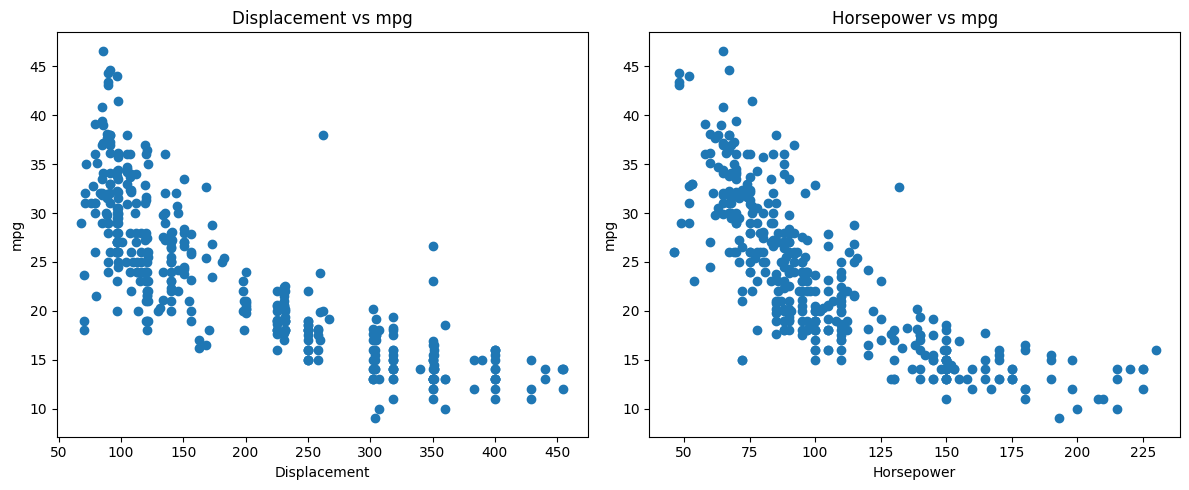


Training Results
RMSE: 3.4559142294242142
R²: 0.8107227953093896

Testing Results
RMSE: 3.240736078334261
R²: 0.7942349075428586


"\nFindings:\n\n- The R² values indicate how much of the variance in 'mpg' is explained by the model.\n  Higher R² suggests a better fit.\n- RMSE indicates the typical error in predicting 'mpg'. Lower RMSE is better.\n- Similar train and test scores suggest that the model\n  generalizes reasonably well and is not heavily overfitting.\n- The specific values will depend on the chosen features and data split.\n"

In [8]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df = pd.read_csv("Auto.csv")

# Handle '?' values in 'horsepower' and convert to numeric
df = df.replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])
df.dropna(inplace=True) # Drop rows with NaN values after conversion

print(df.head())
# --------------------------------------------------
# b) Identify variables
# --------------------------------------------------

print("\nVariables:")
print(df.columns)

"""
Variables in the dataset (Auto.csv):

- mpg (miles per gallon)
- cylinders
- displacement
- horsepower
- weight
- acceleration
- year
- origin
- name

mpg is the target variable.
The others, excluding 'name' and 'origin', are potential explanatory variables.
"""

# --------------------------------------------------
# c) Correlation between variables
# --------------------------------------------------

# 'name' is a text column and 'origin' is categorical/should be excluded from simple numerical correlation
corr = df.drop(columns=["name", "origin"]).corr()

print("\nCorrelation Matrix:")
print(corr)

"""
We inspect correlations with mpg.

Usually:
- displacement, horsepower, and weight have strong negative correlations with mpg.
- cylinders also shows a negative correlation.
- acceleration and year often have positive correlations.

Variables with stronger (absolute) correlation are generally
better predictors of mpg.
"""

# --------------------------------------------------
# d) Choose variables
# --------------------------------------------------

# As per Question 3b, use all variables except 'mpg', 'name', and 'origin'
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']
target = "mpg"

"""
Chosen variables for predicting mpg:

1. cylinders
2. displacement
3. horsepower
4. weight
5. acceleration
6. year

Reason:
These are the numerical features available in the dataset that are not the target ('mpg')
or text/categorical columns to be excluded ('name', 'origin').
"""

# --------------------------------------------------
# e) Plot explanatory variables against mpg
# --------------------------------------------------

# Plotting a couple of the chosen explanatory variables against the target 'mpg'
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df["displacement"], df["mpg"])
plt.xlabel("Displacement")
plt.ylabel("mpg")
plt.title("Displacement vs mpg")

plt.subplot(1,2,2)
plt.scatter(df["horsepower"], df["mpg"])
plt.xlabel("Horsepower")
plt.ylabel("mpg")
plt.title("Horsepower vs mpg")

plt.tight_layout()
plt.show()

"""
The scatter plots should show relationships between the selected features and mpg.
For example, displacement and horsepower often show a negative, roughly linear trend
with mpg, which supports using linear regression.
"""

# --------------------------------------------------
# f) Train-test split (80/20)
# --------------------------------------------------

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# --------------------------------------------------
# g) Train linear regression model
# --------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# --------------------------------------------------
# h) RMSE and R² for train and test
# --------------------------------------------------

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("\nTraining Results")
print("RMSE:", train_rmse)
print("R²:", train_r2)

print("\nTesting Results")
print("RMSE:", test_rmse)
print("R²:", test_r2)

"""
Findings:

- The R² values indicate how much of the variance in 'mpg' is explained by the model.
  Higher R² suggests a better fit.
- RMSE indicates the typical error in predicting 'mpg'. Lower RMSE is better.
- Similar train and test scores suggest that the model
  generalizes reasonably well and is not heavily overfitting.
- The specific values will depend on the chosen features and data split.
"""